# EDA рекомендательной системы

Запускайте из каталога `generate_data` (или поправьте `ROOT` в первой ячейке). Нужны: миграции, данные в БД (`import_projects_dataset`, `seed_recommendation_demo`), зависимости из `2025_hse_dsa/requirements.txt` и скачанная модель MiniLM.

In [1]:
# pip install matplotlib pandas 

In [2]:
!pwd

/Users/user/Desktop/Учеба/cursach/generate_data


In [1]:
import os
import sys

import django

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '2025_hse_dsa', 'src'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'config.settings')
os.environ.setdefault('DJANGO_ALLOW_ASYNC_UNSAFE', 'true')  # для Jupyter

os.environ['POSTGRES_HOST'] = 'localhost'
os.environ['POSTGRES_PORT'] = '5433'

django.setup()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from django.contrib.auth import get_user_model
from django.db.models import Count

from apps.projects.models import Application, Project, Tag
from apps.projects.services import (
    COLLAB_WEIGHT,
    GRADES_WEIGHT,
    SEMANTIC_WEIGHT,
    TAG_WEIGHT,
    _collaborative_scores,
    _grades_scores,
    _semantic_scores,
    _tag_scores,
    get_recommended_projects,
)

User = get_user_model()

In [9]:
projects = list(Project.objects.prefetch_related('tags', 'participants'))
students = list(User.objects.filter(role=User.Role.STUDENT).prefetch_related('interests'))
apps = Application.objects.values('project_id').annotate(n=Count('id'))
app_df = pd.DataFrame(list(apps))
print('projects', len(projects), 'students', len(students))
display(app_df.describe())

projects 205 students 154


,project_id,n
count,154.000000,154.000000
mean,111.233766,3.792208
std,61.263045,3.247272
min,1.000000,1.000000
25%,58.750000,1.000000
50%,118.000000,2.500000
75%,164.500000,6.000000
max,205.000000,16.000000


,id,n_tags,title_len,desc_len
count,205.000000,205.000000,205.000000,205.000000
mean,103.000000,3.468293,79.390244,242.326829
std,59.322565,0.638027,30.831196,59.619509
min,1.000000,2.000000,17.000000,47.000000
25%,52.000000,3.000000,58.000000,195.000000
50%,103.000000,4.000000,76.000000,228.000000
75%,154.000000,4.000000,97.000000,296.000000
max,205.000000,5.000000,176.000000,347.000000


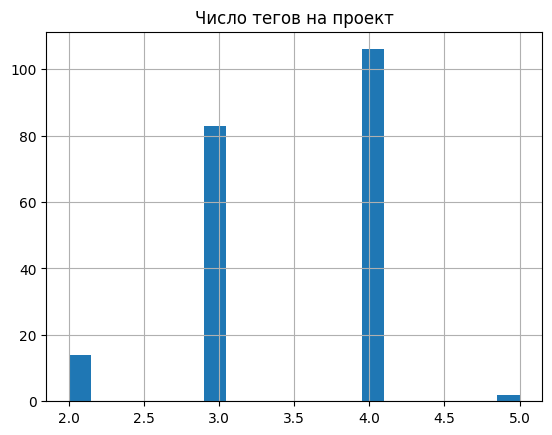

In [10]:
rows = []
for p in projects:
    rows.append(
        {
            'id': p.pk,
            'n_tags': p.tags.count(),
            'title_len': len(p.title or ''),
            'desc_len': len(p.description or ''),
            'has_embedding': bool(p.embedding),
        }
    )
pdf = pd.DataFrame(rows)
display(pdf.describe())
pdf['n_tags'].hist(bins=20)
plt.title('Число тегов на проект')
plt.show()

In [11]:
srows = []
for u in students:
    gj = u.grades_json or {}
    srows.append(
        {
            'id': u.pk,
            'n_interests': u.interests.count(),
            'bio_len': len(u.bio or ''),
            'cover_len': len(u.cover_letter or ''),
            'n_grades': len(gj) if isinstance(gj, dict) else 0,
            'n_grade_profile': len(u.grade_profile or {}),
            'has_profile_emb': bool(u.profile_embedding),
        }
    )
sdf = pd.DataFrame(srows)
display(sdf.describe())

,id,n_interests,bio_len,cover_len,n_grades,n_grade_profile
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,205.123377,2.993506,239.000000,374.896104,2.915584,2.922078
std,54.123235,0.851732,56.837459,87.273978,0.976530,0.987057
min,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,170.250000,2.000000,208.000000,331.250000,2.000000,2.000000
50%,208.500000,3.000000,230.500000,351.000000,3.000000,3.000000
75%,246.750000,4.000000,281.750000,439.750000,4.000000,4.000000
max,285.000000,4.000000,351.000000,522.000000,4.000000,5.000000


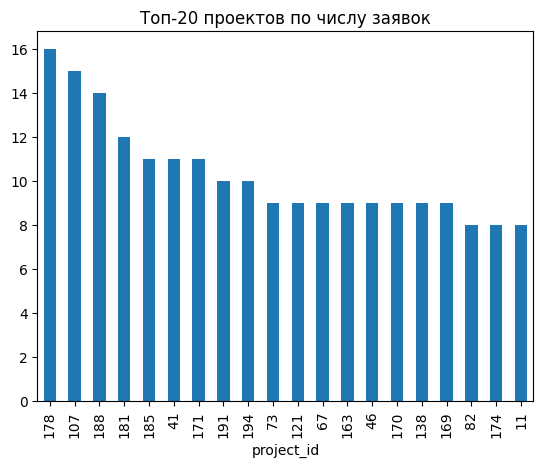

In [12]:
app_df.sort_values('n', ascending=False).head(20).plot(x='project_id', y='n', kind='bar', legend=False)
plt.title('Топ-20 проектов по числу заявок')
plt.show()

In [13]:
def raw_vectors(user, projects):
    tag = _tag_scores(user, projects)
    collab = _collaborative_scores(user, projects)
    sem = _semantic_scores(user, projects)
    gr = _grades_scores(user, projects)
    return tag, collab, sem, gr


coverage = {'tag': 0, 'collab': 0, 'sem': 0, 'gr': 0}
for u in students[:200]:
    cand = [p for p in projects if p.status == Project.Status.RECRUITMENT]
    if not cand:
        continue
    t, c, s, g = raw_vectors(u, cand)
    coverage['tag'] += int(bool(t))
    coverage['collab'] += int(bool(c))
    coverage['sem'] += int(bool(s))
    coverage['gr'] += int(bool(g))
print('coverage (first 200 students):', coverage)

coverage (first 200 students): {'tag': 154, 'collab': 154, 'sem': 150, 'gr': 150}


In [14]:
def rank_ids(user, zero_weight):
    from apps.projects import services as S

    old = (S.TAG_WEIGHT, S.COLLAB_WEIGHT, S.SEMANTIC_WEIGHT, S.GRADES_WEIGHT)
    S.TAG_WEIGHT, S.COLLAB_WEIGHT, S.SEMANTIC_WEIGHT, S.GRADES_WEIGHT = zero_weight
    try:
        qs = get_recommended_projects(user)
        return [p.pk for p in qs]
    finally:
        S.TAG_WEIGHT, S.COLLAB_WEIGHT, S.SEMANTIC_WEIGHT, S.GRADES_WEIGHT = old


base_w = (TAG_WEIGHT, COLLAB_WEIGHT, SEMANTIC_WEIGHT, GRADES_WEIGHT)
ablations = [
    ('no_tag', (0.0, COLLAB_WEIGHT, SEMANTIC_WEIGHT, GRADES_WEIGHT)),
    ('no_collab', (TAG_WEIGHT, 0.0, SEMANTIC_WEIGHT, GRADES_WEIGHT)),
    ('no_sem', (TAG_WEIGHT, COLLAB_WEIGHT, 0.0, GRADES_WEIGHT)),
    ('no_gr', (TAG_WEIGHT, COLLAB_WEIGHT, SEMANTIC_WEIGHT, 0.0)),
]
sample = [u for u in students if u.interests.exists()][:30]
for name, w in ablations:
    corrs = []
    for u in sample:
        cand = [p for p in projects if p.status == Project.Status.RECRUITMENT]
        if len(cand) < 3:
            continue
        a = rank_ids(u, base_w)
        b = rank_ids(u, w)
        common = [x for x in a if x in b]
        if len(common) < 3:
            continue
        ia = [a.index(x) for x in common]
        ib = [b.index(x) for x in common]
        corrs.append(pd.Series(ia).corr(pd.Series(ib), method='spearman'))
    m = float(np.nanmean(corrs)) if corrs else float('nan')
    print(name, 'mean_spearman_vs_base', m)

no_tag mean_spearman_vs_base 0.9292458351124268
no_collab mean_spearman_vs_base 0.893860462284393
no_sem mean_spearman_vs_base 0.901856568654481
no_gr mean_spearman_vs_base 0.9863001294743676


In [15]:
import random

rng = random.Random(42)
sample_users = rng.sample(students, k=min(5, len(students)))
for u in sample_users:
    print('--- user', u.pk, u.username)
    print('interests:', list(u.interests.values_list('name', flat=True)))
    print('bio:', (u.bio or '')[:120])
    rec = list(get_recommended_projects(u))[:10]
    cand = [p for p in projects if p.status == Project.Status.RECRUITMENT]
    t, c, s, g = raw_vectors(u, cand)
    for p in rec:
        print(
            p.pk,
            p.title[:60],
            'tag',
            round(t.get(p.pk, 0), 3),
            'collab',
            round(c.get(p.pk, 0), 3),
            'sem',
            round(s.get(p.pk, 0), 3),
            'gr',
            round(g.get(p.pk, 0), 3),
        )

--- user 282 synthetic_student_147
interests: ['Analytics', 'Computer Vision', 'NLP']
bio: Студент 1 курса ПМИ в Санкт-Петербурге. Развиваюсь как Backend и Web-разработчик. Имею базовый опыт работы с серверными 
42 Ресурсо-эффективная тонкая настройка больших языковых моделе tag 0.167 collab 0.415 sem 0.853 gr 0.9
22 Оптимизация деятельности компании с использованием искусстве tag 0.167 collab 0.431 sem 0.747 gr 0.7
201 Стажировка как инструмент привлечения сотрудников в организа tag 0.2 collab 0.325 sem 0.775 gr 0.7
12 Алгоритмы для задач целочисленного программирования tag 0.2 collab 0.081 sem 0.938 gr 0.7
104 Распознавание эмоций (для Буренковой Анны) tag 0.167 collab 0.398 sem 0.437 gr 1.0
13 Методология оценки качества алгоритмов для решения задачи по tag 0.167 collab 0.228 sem 0.693 gr 0.9
110 Исследование влияния корпоративного управления на финансовые tag 0.167 collab 0.488 sem 0.404 gr 0.7
143 Оценка эффективности функционирования логистических систем tag 0.167 collab 0.195 se